In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
    
from functions import TextLiDARPairDataset, collate_text_lidar_pairs, filter_small_pointclouds
from utils.processing import sparse_to_dense
from utils.visualize import visualize_point_cloud

import torch

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
SparseCLIP_dataset = torch.load('/home/ximeng/Documents/SparseCLIP/expired/nuscenes_tp_train.pt')
filtered_dataset = filter_small_pointclouds(SparseCLIP_dataset, min_points=5)

Filtering small pointclouds: 100%|██████████| 931582/931582 [00:00<00:00, 1558461.83it/s]

Original samples: 931582
Filtered out (less than 5 points): 491612
Remaining samples: 439970


In [3]:
SparseCLIP_train_dataloader = torch.utils.data.DataLoader(
    filtered_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=lambda batch: collate_text_lidar_pairs(batch, sparse_to_dense_fn=sparse_to_dense)
)

In [4]:
for batch in SparseCLIP_train_dataloader:
    sample = batch
    print(sample)
    break

(['apointcloud of car', 'apointcloud of car', 'apointcloud of car', 'apointcloud of bicycle', 'apointcloud of debris', 'apointcloud of truck', 'apointcloud of car', 'apointcloud of truck', 'apointcloud of trailer', 'apointcloud of car', 'apointcloud of trailer', 'apointcloud of pedestrian', 'apointcloud of truck', 'apointcloud of trailer', 'apointcloud of trafficcone', 'apointcloud of trafficcone', 'apointcloud of car', 'apointcloud of pedestrian', 'apointcloud of truck', 'apointcloud of barrier', 'apointcloud of barrier', 'apointcloud of car', 'apointcloud of bus', 'apointcloud of car', 'apointcloud of pedestrian', 'apointcloud of car', 'apointcloud of car', 'apointcloud of barrier', 'apointcloud of pushable_pullable', 'apointcloud of truck', 'apointcloud of pedestrian', 'apointcloud of car', 'apointcloud of car', 'apointcloud of car', 'apointcloud of car', 'apointcloud of pedestrian', 'apointcloud of barrier', 'apointcloud of barrier', 'apointcloud of car', 'apointcloud of car', 'apo

apointcloud of car
torch.Size([1024, 3])


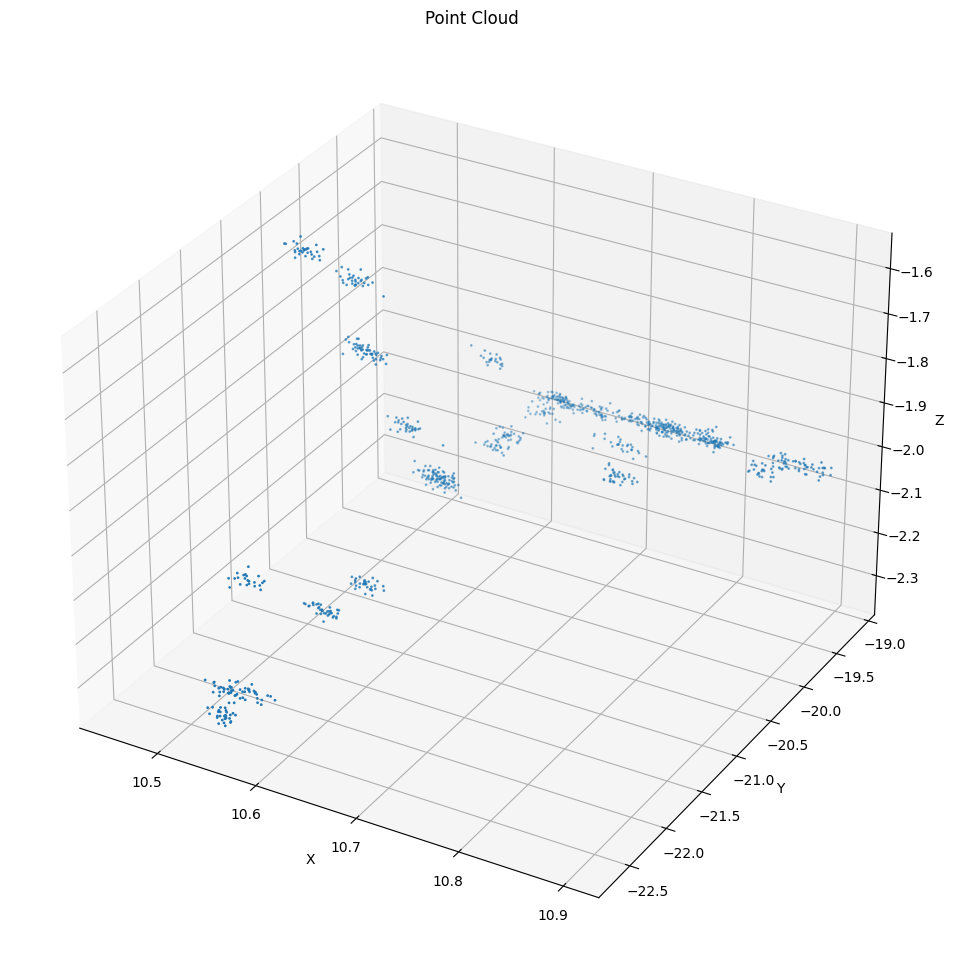

In [5]:
# [2, Batch size]
batch = 0
print(sample[0][batch]) # string label

points = sample[1][batch]
print(points.shape) # point cloud tensor
visualize_point_cloud(points)

In [6]:
len(sample[0])

128

torch.Size([1024, 3])


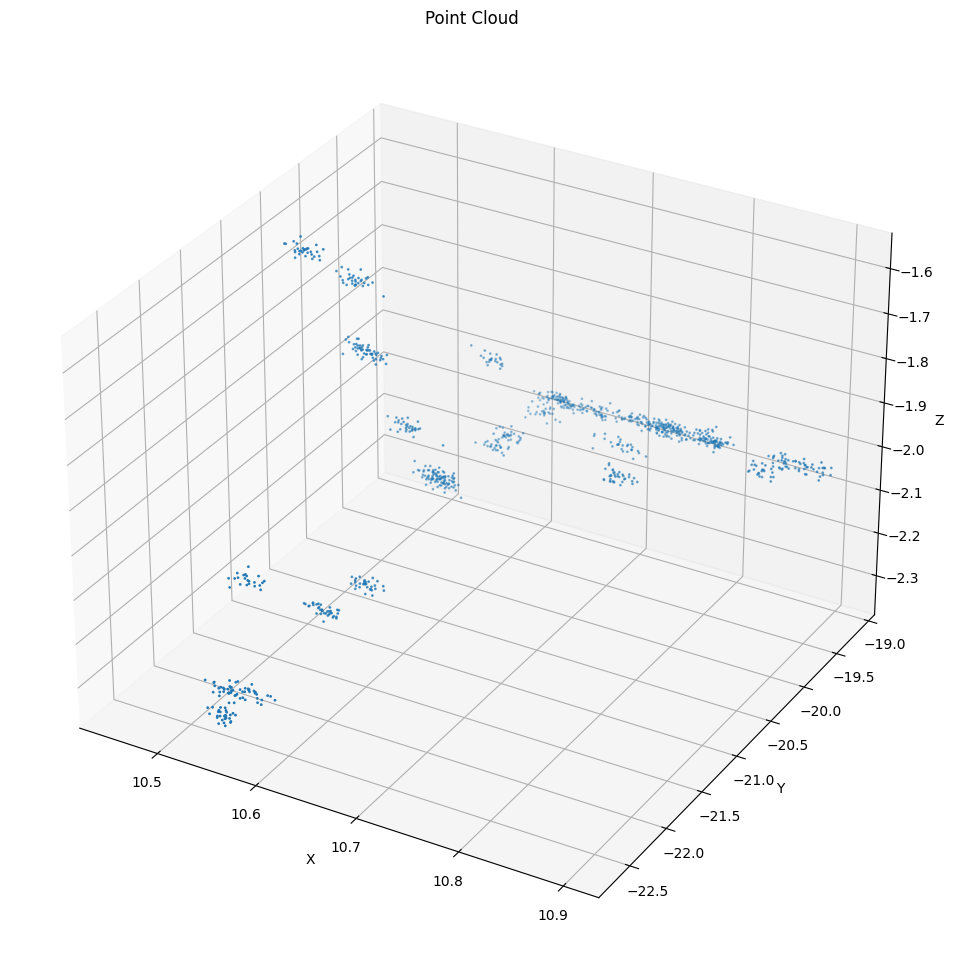

In [7]:
pt2 = sparse_to_dense(sample[1][batch])
print(pt2.shape)  # [target_num_points, 3]
visualize_point_cloud(pt2)

In [8]:
type(sample[0])

list

In [9]:
sample[1].shape

torch.Size([128, 1024, 3])